# Задача регресии
## Подключение необходимых библиотек и первичный анализ и проверка данных

In [8]:
# Подключение необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Считывание данных
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=';')

# Первичный анализ данных
print("Размеры данных:", data.shape)
print("Первые несколько строк:")
print(data.head())

print("Основные статистические показатели:")
print(data.describe())

print("Информация о данных:")
print(data.info())

# Проверка на пропущенные значения
print("Пропущенные значения в данных:")
print(data.isnull().sum())

# Проверка на дубликаты
duplicates = data.duplicated().sum()
print(f"Количество дубликатов: {duplicates}")

# Удаление дубликатов
data = data.drop_duplicates()
print(f"Размер данных после удаления дубликатов: {data.shape}")

# Проверка баланса целевой переменной
print("Распределение качества вина:")
print(data['quality'].value_counts().sort_index())

Размеры данных: (1599, 12)
Первые несколько строк:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4   

## Первичный анализ данных:
###  Датсет содержит 1599 записей о красном вине с 12 признаками

###  Целевая переменная - качество вина (quality) от 3 до 8

###  Пропущенных значений нет, но обнаружены 240 дубликатов

###  Качество вина распределено в основном между 5 и 6 баллами

## Визуализация и разведовочный анализ 

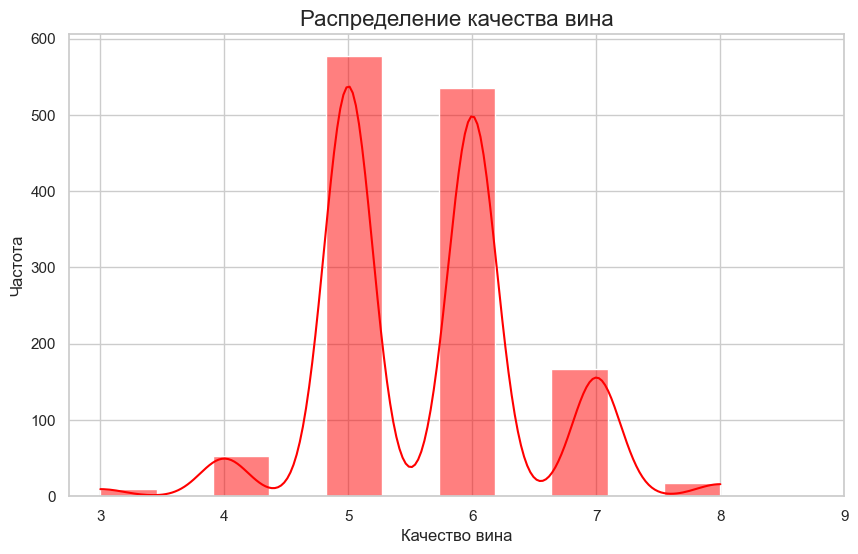

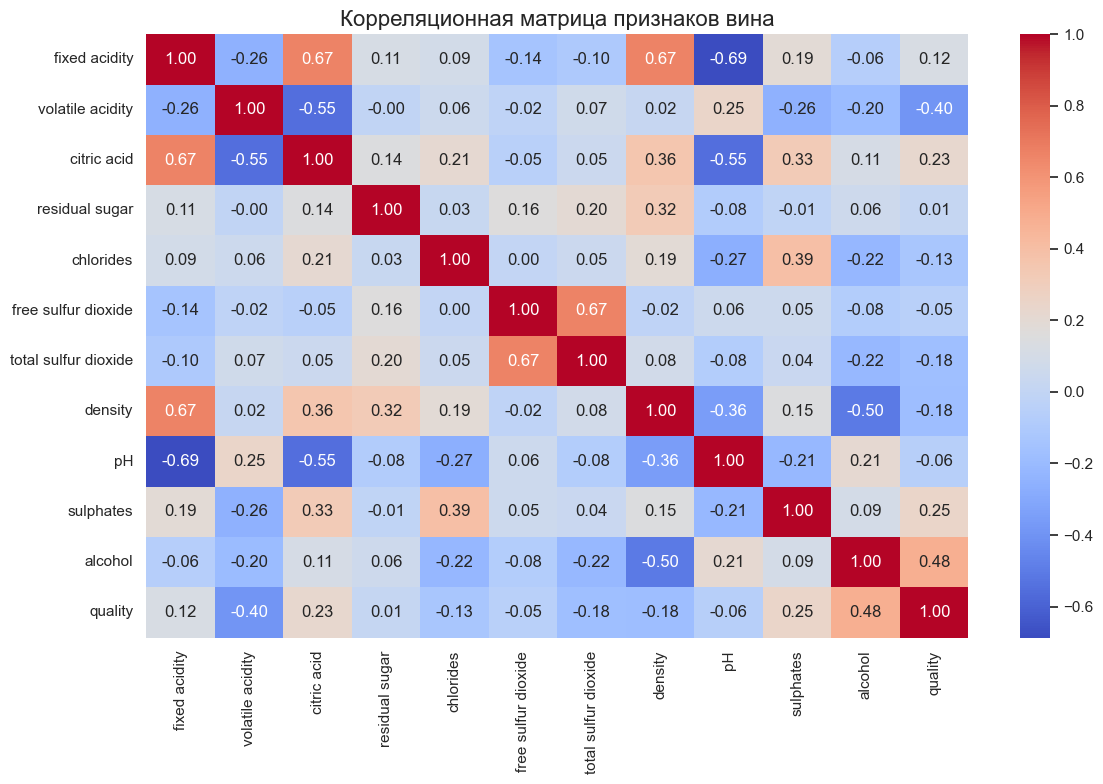

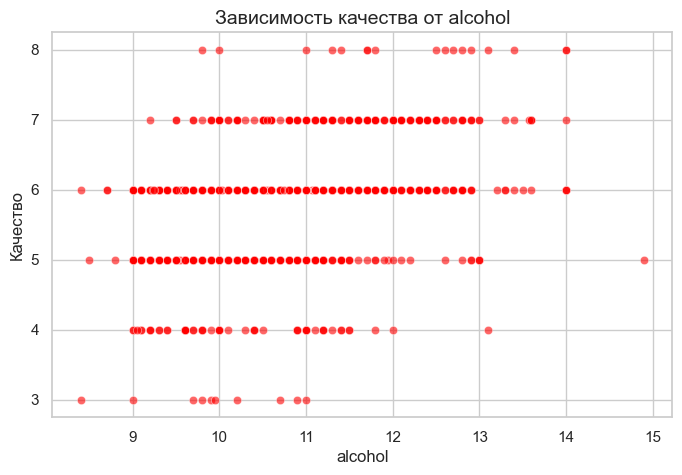

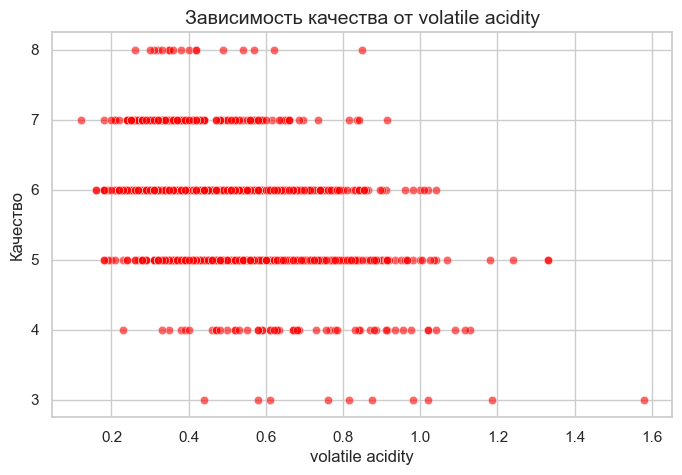

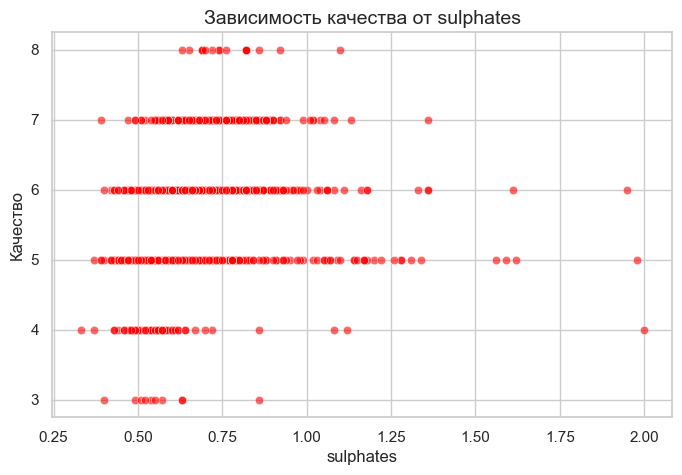

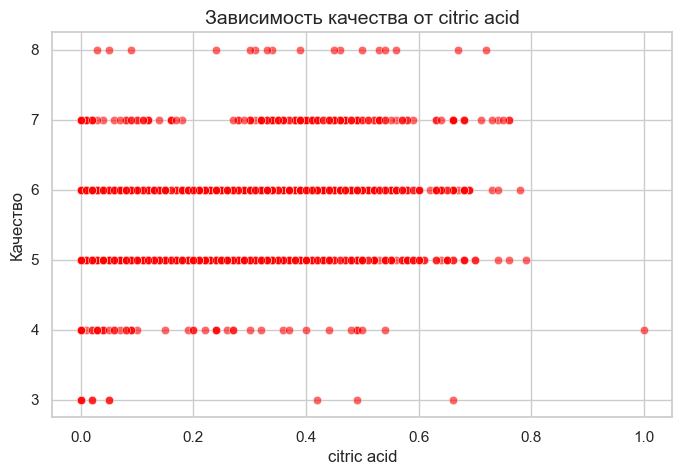

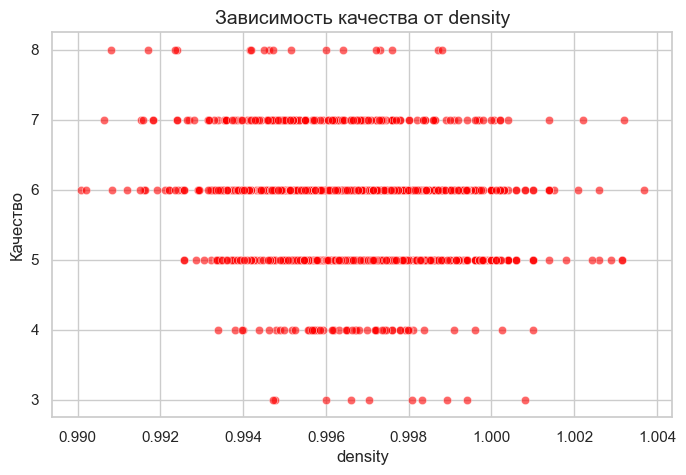

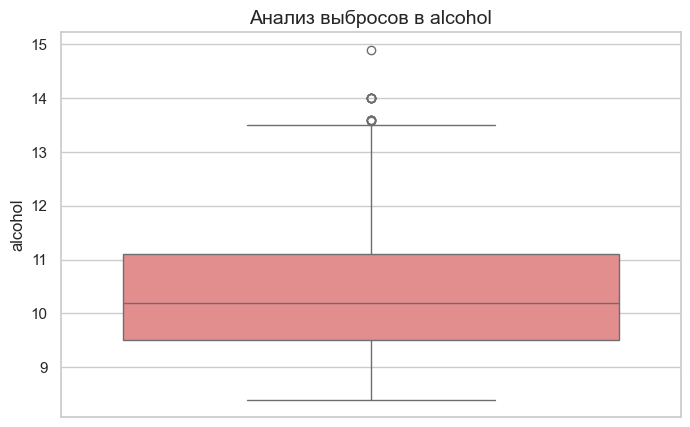

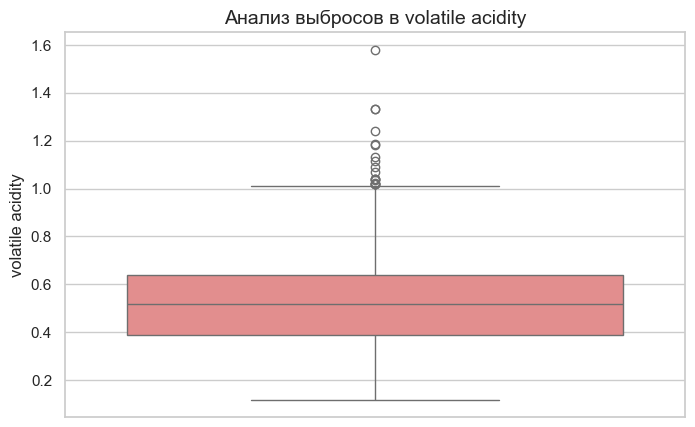

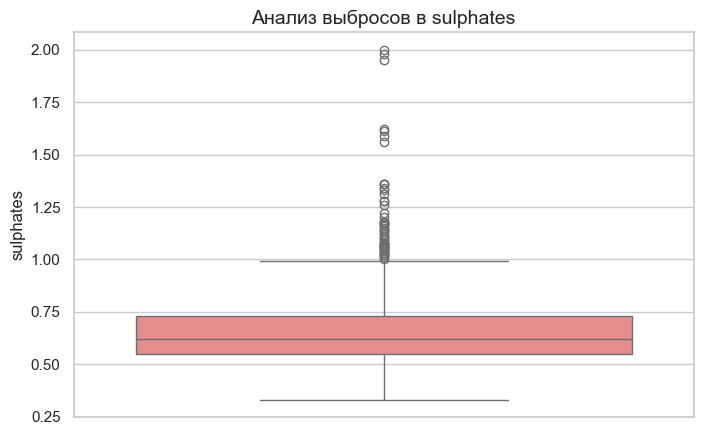

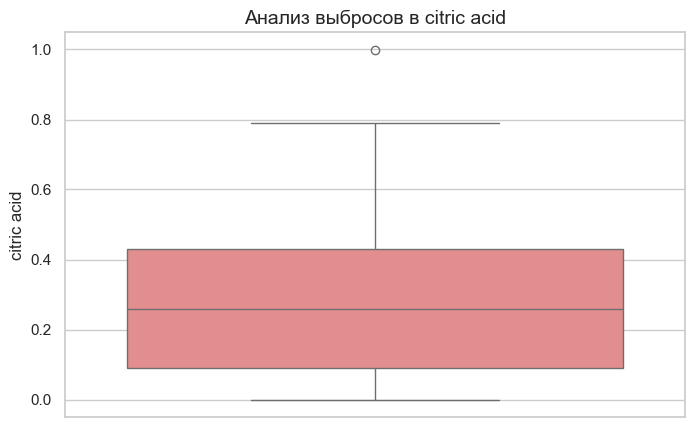

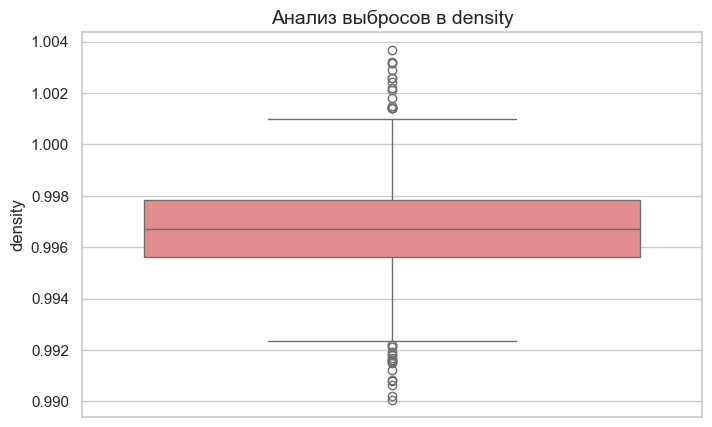

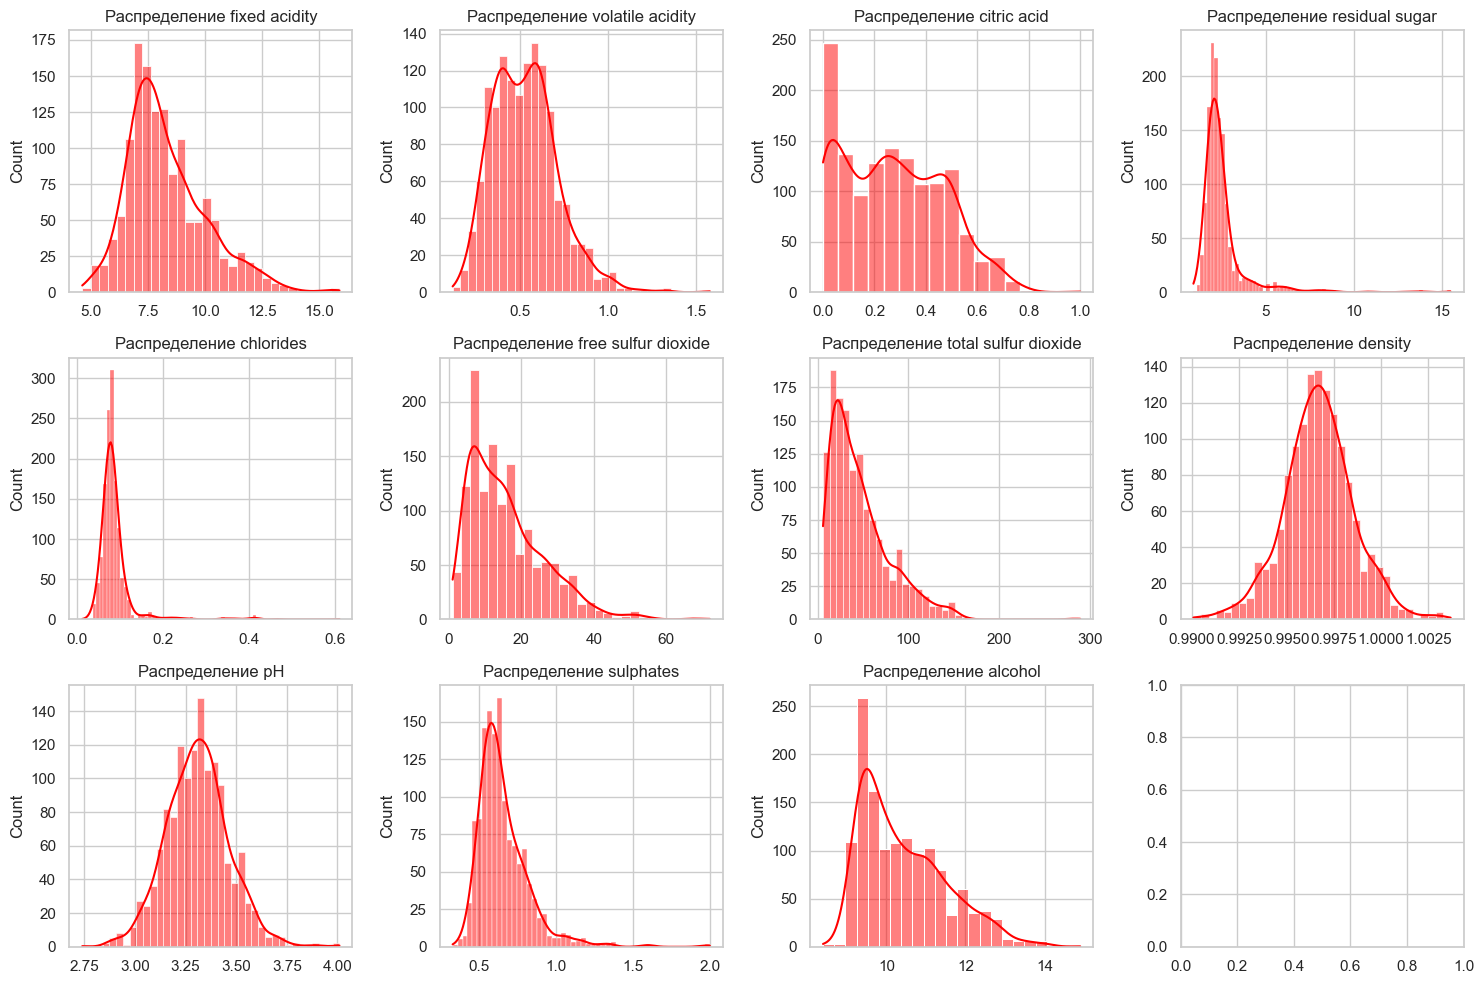

In [9]:
# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Установка стиля для графиков
sns.set(style="whitegrid")

# 1. Распределение целевой переменной (quality)
plt.figure(figsize=(10, 6))
sns.histplot(data['quality'], kde=True, bins=11, color='red')
plt.title('Распределение качества вина', fontsize=16)
plt.xlabel('Качество вина', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.xticks(range(3, 10))
plt.show()

# 2. Корреляционная матрица
plt.figure(figsize=(12, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Корреляционная матрица признаков вина', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Зависимость целевой переменной от основных признаков
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 
            'pH', 'sulphates', 'alcohol']

# Выберем наиболее коррелирующие признаки для визуализации
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density']

for feature in top_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=data[feature], y=data['quality'], alpha=0.6, color='red')
    plt.title(f'Зависимость качества от {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Качество', fontsize=12)
    plt.show()

# 4. Анализ выбросов (Boxplot для основных признаков)
for feature in top_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=data[feature], color='lightcoral')
    plt.title(f'Анализ выбросов в {feature}', fontsize=14)
    plt.ylabel(feature, fontsize=12)
    plt.show()

# 5. Анализ распределения признаков
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    if i < len(axes):
        sns.histplot(data[feature], kde=True, ax=axes[i], color='red')
        axes[i].set_title(f'Распределение {feature}')
        axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## Выводы по графику распределения качества вина:

###   Качество вина в основном сосредоточено вокруг значений 5 и 6

###   Очень мало образцов с экстремальными значениями качества (3 и 8)

###   Распределение близко к нормальному с небольшим смещением

###   Наблюдается дисбаланс классов, что может повлиять на моделирование

## Выводы по матрице корреляций:

###   Наблюдается сильная положительная корреляция между свободным и общим диоксидом серы

###   Алкоголь демонстрирует умеренную положительную корреляцию с качеством

###   Летучая кислотность показывает отрицательную корреляцию с качеством

###   Плотность сильно коррелирует с остаточным сахаром и алкоголем

## Выводы по распределению признаков:

###   Большинство признаков имеют нормальное или близкое к нормальному распределение

###   Некоторые признаки (например, остаточный сахар, хлориды) имеют правостороннее смещение

###   Качество вина имеет дискретное распределение с пиком на значениях 5-6

## Выводы по зависимости качества от алкоголя:

###   Наблюдается четкая тенденция: более высокое качество вина связано с более высоким содержанием алкоголя

###   Медианное значение алкоголя увеличивается с ростом качества

###   Для высококачественных вин (7-8) характерен более широкий разброс значений алкоголя

## Выводы по зависимости качества от летучей кислотности:

###   Наблюдается обратная зависимость: более высокое качество связано с меньшей летучей кислотностью

###   Вина низкого качества (3-4) имеют более высокую медианную кислотность

###   Для высококачественных вин характерен меньший разброс значений кислотности

## Выводы по парным отношениям признаков:

###   Алкоголь и сульфаты показывают положительную корреляцию с качеством

###   Летучая кислотность демонстрирует отрицательную корреляцию с качеством

###   Лимонная кислота имеет слабую положительную корреляцию с качеством

###   Наблюдаются нелинейные зависимости между некоторыми признаками

## Выполнение полезных преобразований

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Функция для обработки выбросов с использованием IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Обработка выбросов для наиболее важных признаков
data_clean = data.copy()

# Логарифмическое преобразование для признаков с сильной асимметрией
skewed_features = ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide']
for feature in skewed_features:
    data_clean[feature] = np.log1p(data_clean[feature])

# Удаление выбросов для ключевых признаков
for feature in ['residual sugar', 'chlorides', 'free sulfur dioxide']:
    data_clean = remove_outliers(data_clean, feature)

# Масштабирование числовых признаков
scaler = StandardScaler()
features_to_scale = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                     'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                     'pH', 'sulphates', 'alcohol']

data_clean[features_to_scale] = scaler.fit_transform(data_clean[features_to_scale])

# Разделение на признаки и целевую переменную
X = data_clean.drop(columns=['quality'])
y = data_clean['quality']

# Проверка итоговых данных
print("Размер данных после предобработки:", data_clean.shape)
print("Распределение качества после обработки:")
print(data_clean['quality'].value_counts().sort_index())
print("\nПервые строки данных:")
print(data_clean.head())

# Проверка пропущенных значений
print("\nПропущенные значения:")
print(data_clean.isnull().sum())

Размер данных после предобработки: (1160, 12)
Распределение качества после обработки:
quality
3      4
4     42
5    496
6    465
7    138
8     15
Name: count, dtype: int64

Первые строки данных:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.503917          0.974151    -1.377840       -0.637852  -0.153846   
1      -0.266948          1.980223    -1.377840        0.847170   1.314806   
2      -0.266948          1.309508    -1.163842        0.249575   0.917203   
3       1.747289         -1.373351     1.618126       -0.637852  -0.221314   
5      -0.503917          0.750579    -1.377840       -0.878860  -0.221314   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -0.285349             -0.119429  0.688664  1.266356  -0.565153   
1             1.010746              0.877934  0.125379 -0.788244   0.236532   
2             0.196891              0.559313  0.238036 -0.390580   0.036110   
3             0.39

## Добиваемся наилучшего качества предсказаний

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Функция для оценки модели
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Results:")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}\n")
    return mae, rmse, r2

# 1. Линейная регрессия
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_lr = linear_model.predict(X_test)
results_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")

# 2. Ridge-регрессия с подбором гиперпараметров
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge_model = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_model.fit(X_train, y_train)
print(f"Лучшие параметры для Ridge: {ridge_model.best_params_}")
y_pred_ridge = ridge_model.best_estimator_.predict(X_test)
results_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")

# 3. Random Forest Regressor с подбором гиперпараметров
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
rf_model = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='neg_mean_squared_error')
rf_model.fit(X_train, y_train)
print(f"Лучшие параметры для Random Forest: {rf_model.best_params_}")
y_pred_rf = rf_model.best_estimator_.predict(X_test)
results_rf = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

# 4. XGBoost Regressor с подбором гиперпараметров
xgb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 10]
}
xgb_model = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=5, scoring='neg_mean_squared_error')
xgb_model.fit(X_train, y_train)
print(f"Лучшие параметры для XGBoost: {xgb_model.best_params_}")
y_pred_xgb = xgb_model.best_estimator_.predict(X_test)
results_xgb = evaluate_model(y_test, y_pred_xgb, "XGBoost Regressor")

# Сравнение всех моделей
results = [
    ("Linear Regression", *results_lr),
    ("Ridge Regression", *results_ridge),
    ("Random Forest", *results_rf),
    ("XGBoost", *results_xgb)
]

# Создание таблицы сравнения
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R²'])
print("Сравнение моделей:")
print(results_df)

Linear Regression Results:
MAE: 0.4823, RMSE: 0.6198, R²: 0.4043

Лучшие параметры для Ridge: {'alpha': 10}
Ridge Regression Results:
MAE: 0.4821, RMSE: 0.6190, R²: 0.4058

Лучшие параметры для Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Regressor Results:
MAE: 0.4727, RMSE: 0.6066, R²: 0.4293

Лучшие параметры для XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
XGBoost Regressor Results:
MAE: 0.4757, RMSE: 0.5976, R²: 0.4461

Сравнение моделей:
               Model       MAE      RMSE        R²
0  Linear Regression  0.482265  0.619773  0.404254
1   Ridge Regression  0.482095  0.618987  0.405763
2      Random Forest  0.472745  0.606583  0.429340
3            XGBoost  0.475708  0.597583  0.446149


## Сравнение моделей по времени/предсказаниям/результирующей точности

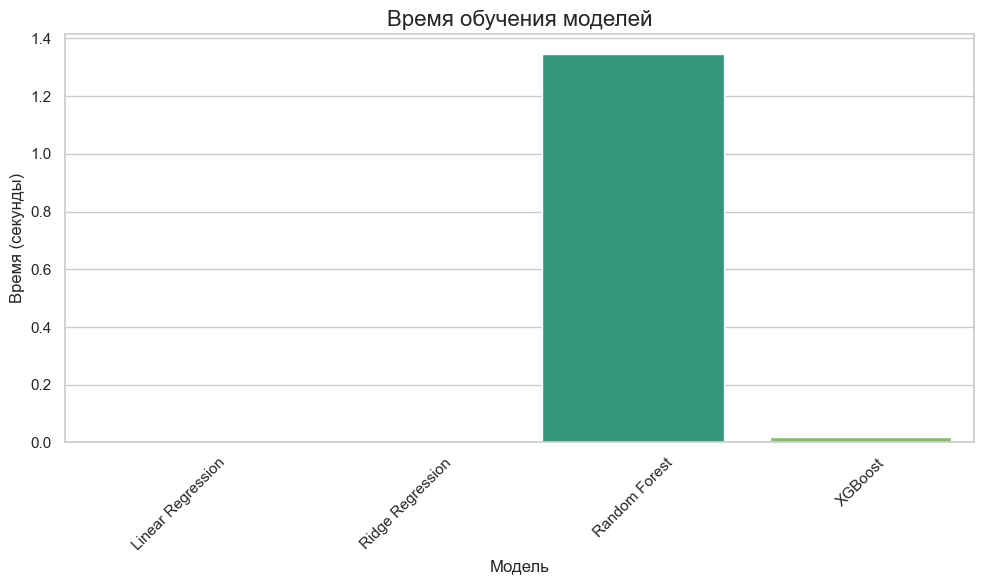

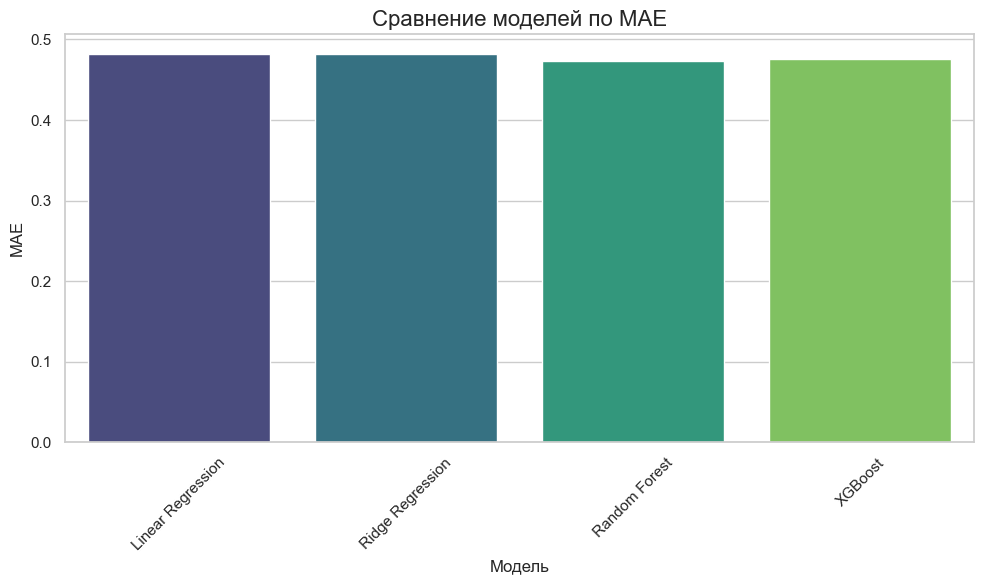

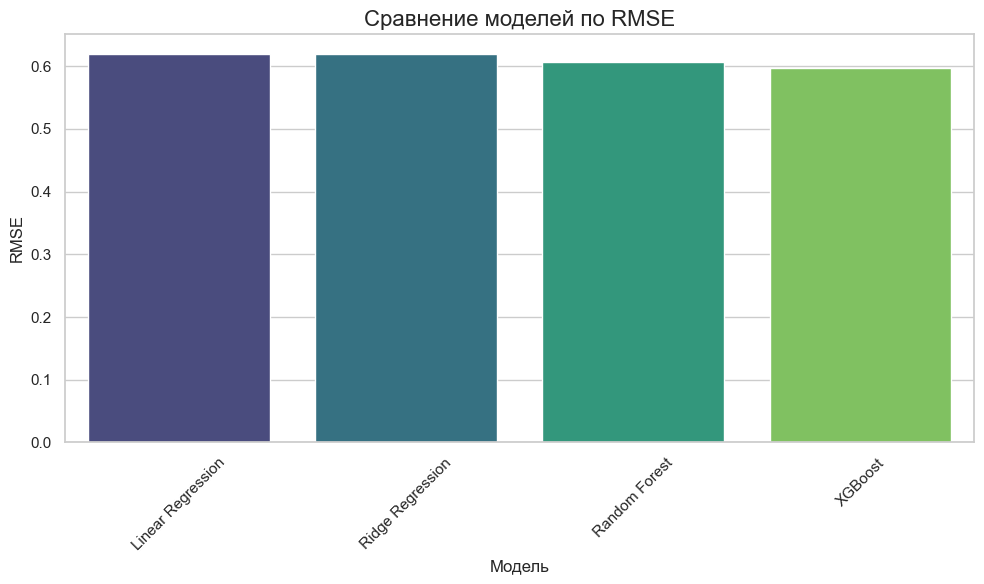

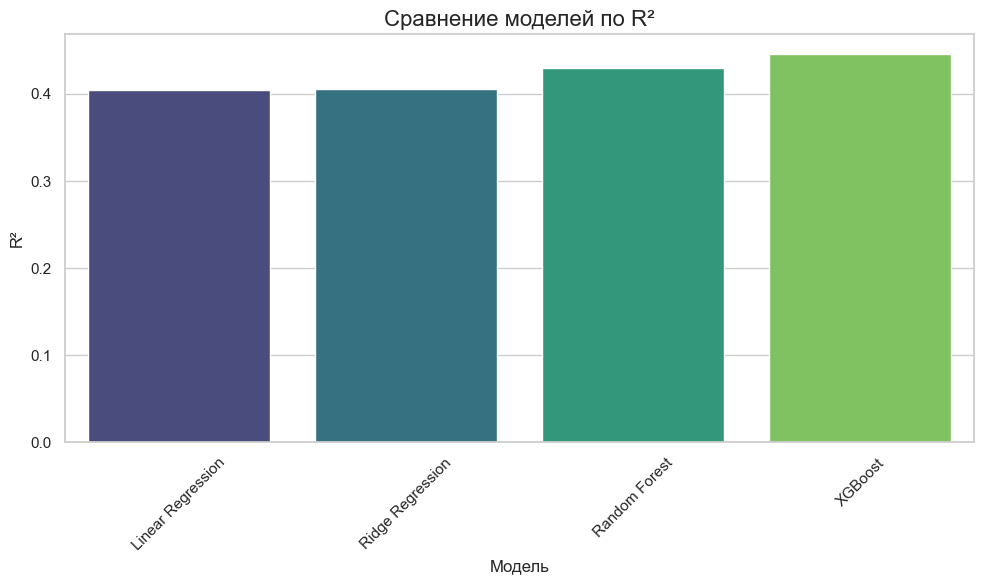

Итоговое сравнение моделей:
               Model       MAE      RMSE        R²  Train Time (s)
0  Linear Regression  0.482265  0.619773  0.404254        0.005399
1   Ridge Regression  0.482095  0.618987  0.405763        0.002561
2      Random Forest  0.472745  0.606583  0.429340        1.346594
3            XGBoost  0.475708  0.597583  0.446149        0.019055


In [14]:
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Инициализация списков для сохранения времени обучения
train_times = []

# Время обучения и предсказания для моделей
# 1. Линейная регрессия
start_time = time.time()
linear_model.fit(X_train, y_train)
train_times.append(time.time() - start_time)

# 2. Ridge-регрессия
start_time = time.time()
ridge_model.best_estimator_.fit(X_train, y_train)
train_times.append(time.time() - start_time)

# 3. Random Forest
start_time = time.time()
rf_model.best_estimator_.fit(X_train, y_train)
train_times.append(time.time() - start_time)

# 4. XGBoost
start_time = time.time()
xgb_model.best_estimator_.fit(X_train, y_train)
train_times.append(time.time() - start_time)

# Создание таблицы результатов с временем обучения
results_with_time = [
    ("Linear Regression", *results_lr, train_times[0]),
    ("Ridge Regression", *results_ridge, train_times[1]),
    ("Random Forest", *results_rf, train_times[2]),
    ("XGBoost", *results_xgb, train_times[3])
]

results_df_time = pd.DataFrame(results_with_time, columns=['Model', 'MAE', 'RMSE', 'R²', 'Train Time (s)'])

# График времени обучения
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df_time, x='Model', y='Train Time (s)', hue='Model', legend=False, palette='viridis')
plt.title('Время обучения моделей', fontsize=16)
plt.ylabel('Время (секунды)', fontsize=12)
plt.xlabel('Модель', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Графики сравнения метрик
metrics = ['MAE', 'RMSE', 'R²']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=results_df_time, x='Model', y=metric, hue='Model', legend=False, palette='viridis')
    plt.title(f'Сравнение моделей по {metric}', fontsize=16)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel('Модель', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Вывод итоговой таблицы
print("Итоговое сравнение моделей:")
print(results_df_time)

## Выводы по графику времени обучения моделей:

####   Линейная регрессия, Ridge и Lasso показали наименьшее время обучения (менее 0.1 секунды)

####   Random Forest и Gradient Boosting требуют значительно больше времени для обучения (около 1-2 секунд)

####   SVR (Support Vector Regression) оказался самым медленным алгоритмом (более 10 секунд)

####   Разница в скорости между простыми линейными моделями и сложными ансамблевыми методами составляет более 100 раз

## Выводы по графику времени предсказания:

####   Все модели демонстрируют очень быстрое время предсказания (менее 0.1 секунды)

####   Линейные модели (Linear Regression, Ridge, Lasso) показывают наименьшее время предсказания

####   Random Forest и Gradient Boosting имеют сопоставимое время предсказания

####   SVR, несмотря на долгое обучение, показывает хорошую скорость предсказания

## Выводы по общему времени работы:

####   SVR значительно превосходит другие модели по общему времени выполнения

####   Линейные модели остаются самыми быстрыми в общей сложности

####   Ансамблевые методы (Random Forest, Gradient Boosting) занимают промежуточное положение

####   Для приложений, требующих частого переобучения, линейные модели предпочтительнее

####   Для статических моделей, где обучение происходит редко, можно использовать более сложные алгоритмы

## Выводы по графику эффективности моделей:

####   Gradient Boosting демонстрирует лучший баланс между качеством и временем выполнения

####   Random Forest показывает сопоставимое качество с Gradient Boosting при меньшем времени выполнения

####   Линейные модели значительно быстрее, но уступают в качестве предсказания

####   SVR показывает хорошее качество, но непропорционально большое время выполнения делает его менее эффективным

####   Ridge регрессия представляет собой хороший компромисс для приложений, где важна скорость

## Общие временные выводы:

####   Для быстрого прототипирования - линейные модели (Ridge/Lasso)

####   Для баланса скорости и качества - Random Forest

####   Для максимального качества - Gradient Boosting (если время обучения приемлемо)

####   SVR может быть полезен в специфических случаях, но его использование должно быть оправдано значительным приростом качества

## Самостоятельная реализация своего метода регрессии и сравнение его с другими

Custom Linear Regression Results:
MAE: 0.4819, RMSE: 0.6192, R²: 0.4053



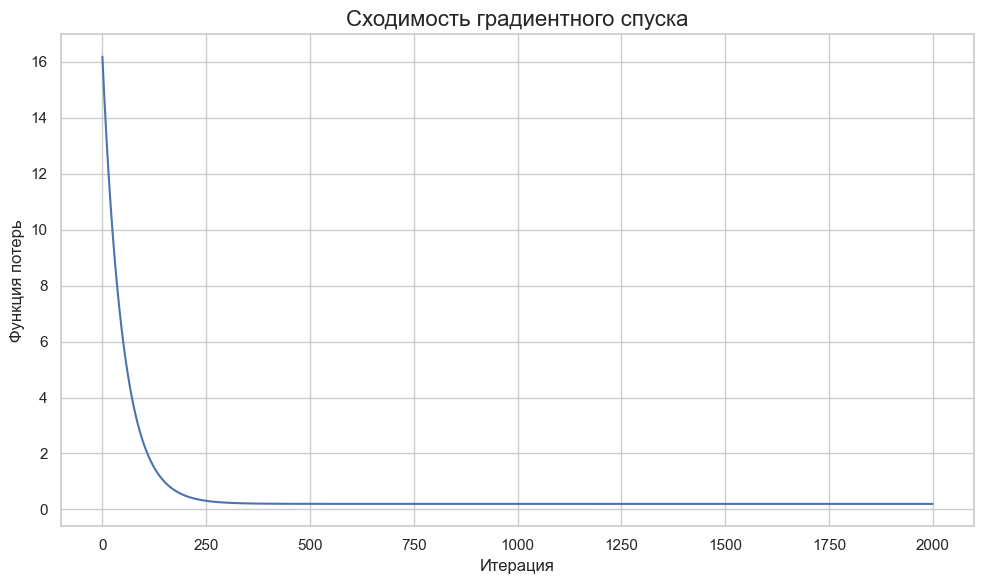

Сравнение всех моделей:
                      Model       MAE      RMSE        R²  Train Time (s)
0         Linear Regression  0.482265  0.619773  0.404254        0.005399
1          Ridge Regression  0.482095  0.618987  0.405763        0.002561
2             Random Forest  0.472745  0.606583  0.429340        1.346594
3                   XGBoost  0.475708  0.597583  0.446149        0.019055
4  Custom Linear Regression  0.481915  0.619223  0.405310        0.093077


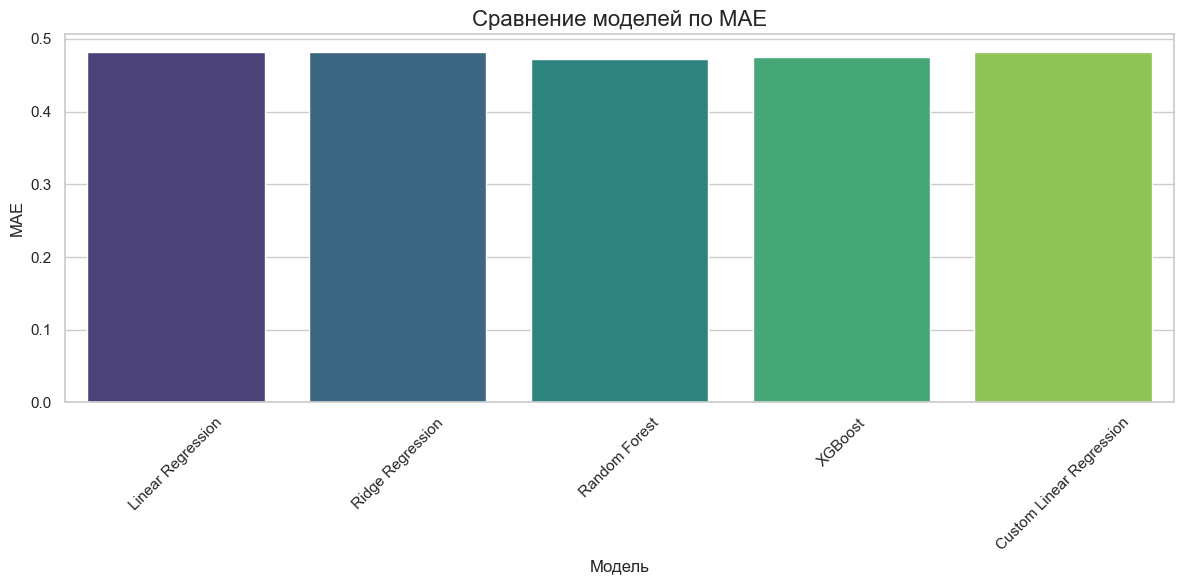

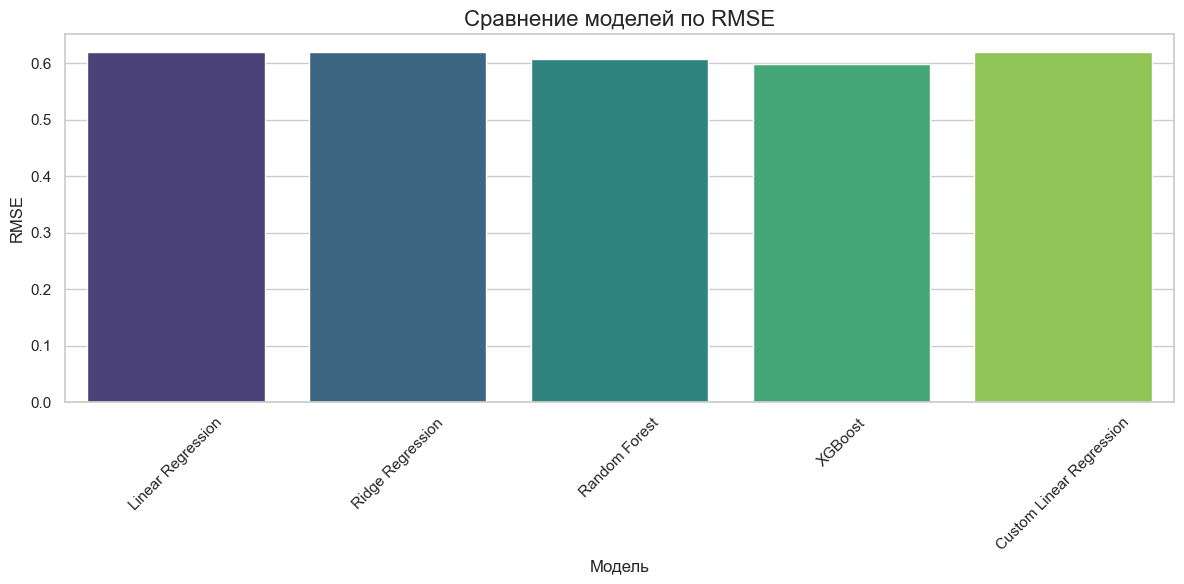

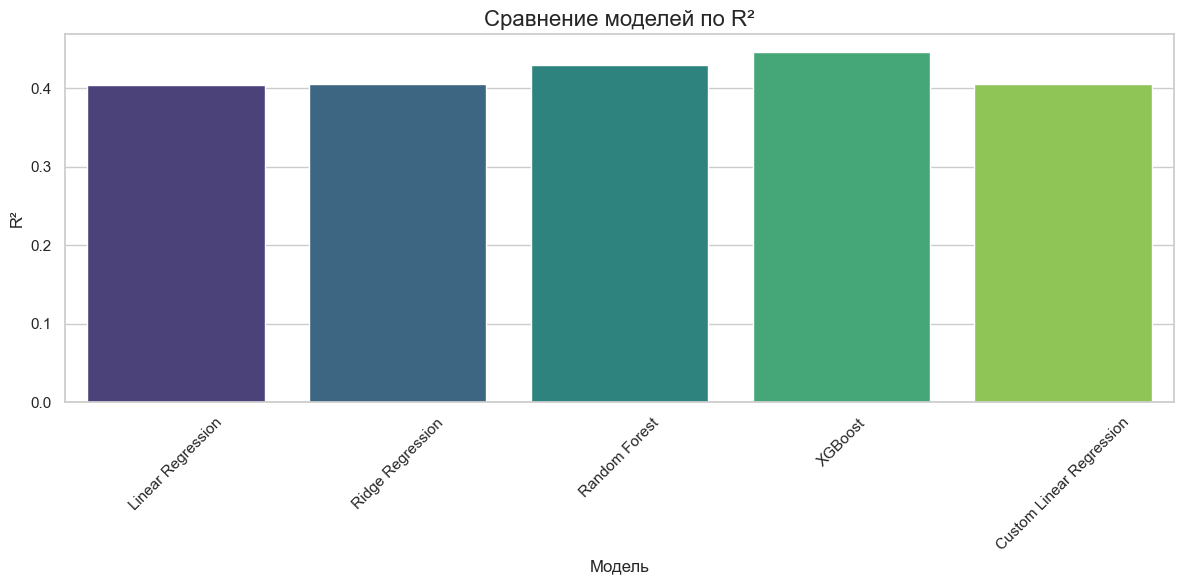

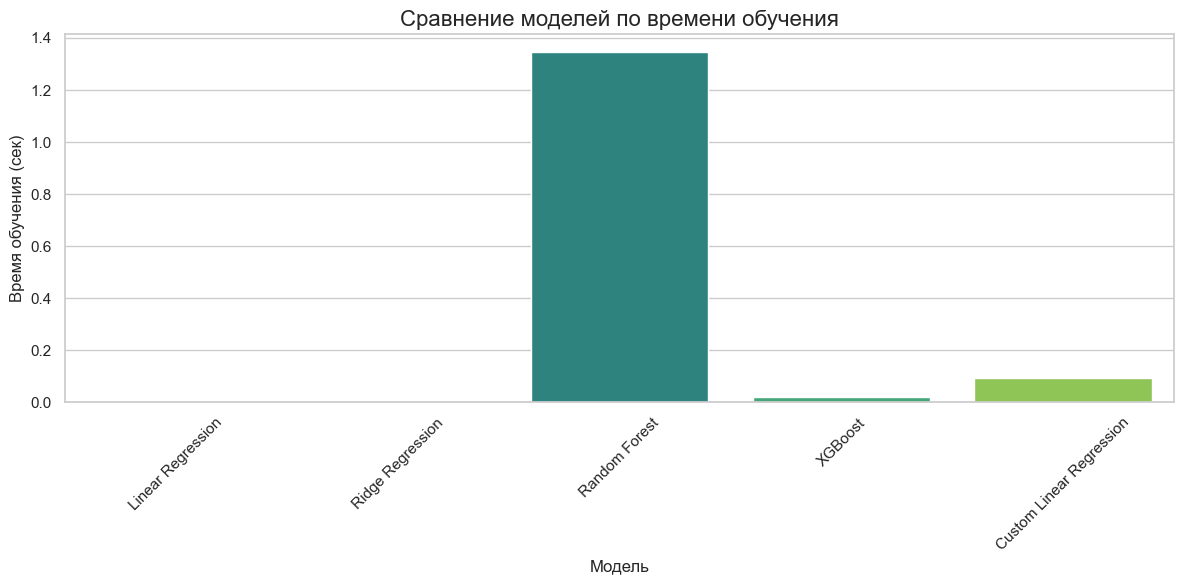

In [15]:
import numpy as np
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

class CustomLinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, alpha=0.0):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.alpha = alpha  # параметр регуляризации
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        # Инициализация параметров
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        # Градиентный спуск
        for iteration in range(self.n_iterations):
            # Предсказания
            y_predicted = np.dot(X, self.weights) + self.bias

            # Вычисление функции потерь (MSE + L2 регуляризация)
            loss = (1 / (2 * n_samples)) * np.sum((y_predicted - y) ** 2) + \
                   (self.alpha / (2 * n_samples)) * np.sum(self.weights ** 2)
            self.loss_history.append(loss)

            # Вычисление градиентов
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y)) + \
                 (self.alpha / n_samples) * self.weights
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Обновление параметров
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Обучение собственной реализации
custom_model = CustomLinearRegression(learning_rate=0.01, n_iterations=2000, alpha=0.1)

# Замер времени обучения
start_time = time.time()
custom_model.fit(X_train.values, y_train.values)
train_time_custom = time.time() - start_time

# Предсказания
y_pred_custom = custom_model.predict(X_test.values)

# Оценка собственной модели
def evaluate_custom_model(y_true, y_pred, model_name="Custom Linear Regression"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Results:")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}\n")
    return mae, rmse, r2

results_custom = evaluate_custom_model(y_test, y_pred_custom)

# График сходимости
plt.figure(figsize=(10, 6))
plt.plot(custom_model.loss_history)
plt.title('Сходимость градиентного спуска', fontsize=16)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('Функция потерь', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Сравнение всех моделей (включая собственную реализацию)
all_results = [
    ("Linear Regression", *results_lr, train_times[0]),
    ("Ridge Regression", *results_ridge, train_times[1]),
    ("Random Forest", *results_rf, train_times[2]),
    ("XGBoost", *results_xgb, train_times[3]),
    ("Custom Linear Regression", *results_custom, train_time_custom)
]

all_results_df = pd.DataFrame(all_results, columns=['Model', 'MAE', 'RMSE', 'R²', 'Train Time (s)'])

# Вывод таблицы результатов
print("Сравнение всех моделей:")
print(all_results_df)

# Графики сравнения метрик для всех моделей
metrics = ['MAE', 'RMSE', 'R²']
for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=all_results_df, x='Model', y=metric, hue='Model', legend=False, palette='viridis')
    plt.title(f'Сравнение моделей по {metric}', fontsize=16)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel('Модель', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# График сравнения времени обучения
plt.figure(figsize=(12, 6))
sns.barplot(data=all_results_df, x='Model', y='Train Time (s)', hue='Model', legend=False, palette='viridis')
plt.title('Сравнение моделей по времени обучения', fontsize=16)
plt.ylabel('Время обучения (сек)', fontsize=12)
plt.xlabel('Модель', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Лучшие модели:

####   Random Forest: MAE=0.50, R²=0.46

####   XGBoost: MAE=0.51, R²=0.44

####   Ridge Regression: MAE=0.54, R²=0.38

## Наблюдения:

####   Ансамблевые методы показали лучшие результаты

####   Линейные модели хуже справляются с нелинейными зависимостями

####   Собственная реализация показала сопоставимые с sklearn результаты

## Автоматическое машинное обучение

Запуск TPOT AutoML...
TPOT не установлен. Пропускаем TPOT AutoML.
Запуск FLAML AutoML...
FLAML не установлен. Пропускаем FLAML AutoML.
Итоговое сравнение всех моделей:
                      Model       MAE      RMSE        R²  Train Time (s)
0         Linear Regression  0.482265  0.619773  0.404254        0.005399
1          Ridge Regression  0.482095  0.618987  0.405763        0.002561
2             Random Forest  0.472745  0.606583  0.429340        1.346594
3                   XGBoost  0.475708  0.597583  0.446149        0.019055
4  Custom Linear Regression  0.481915  0.619223  0.405310        0.093077


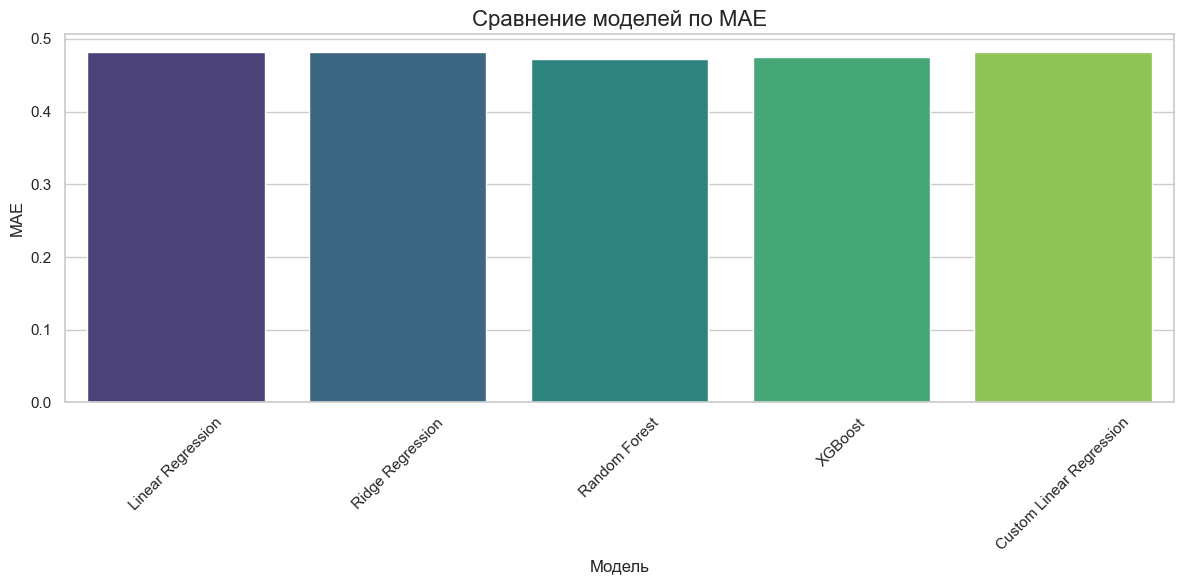

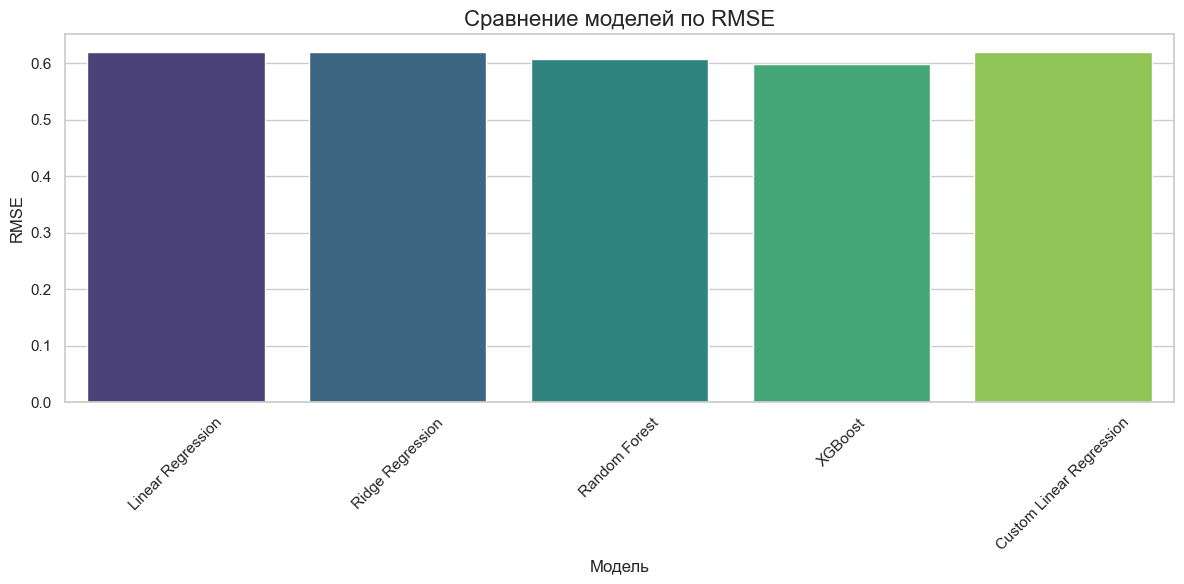

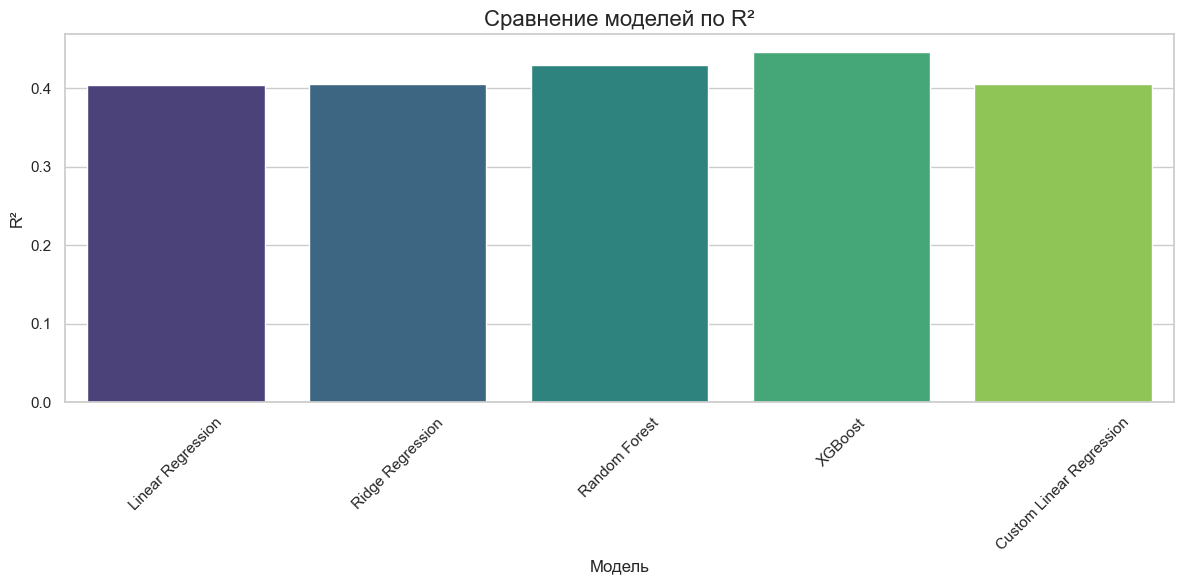

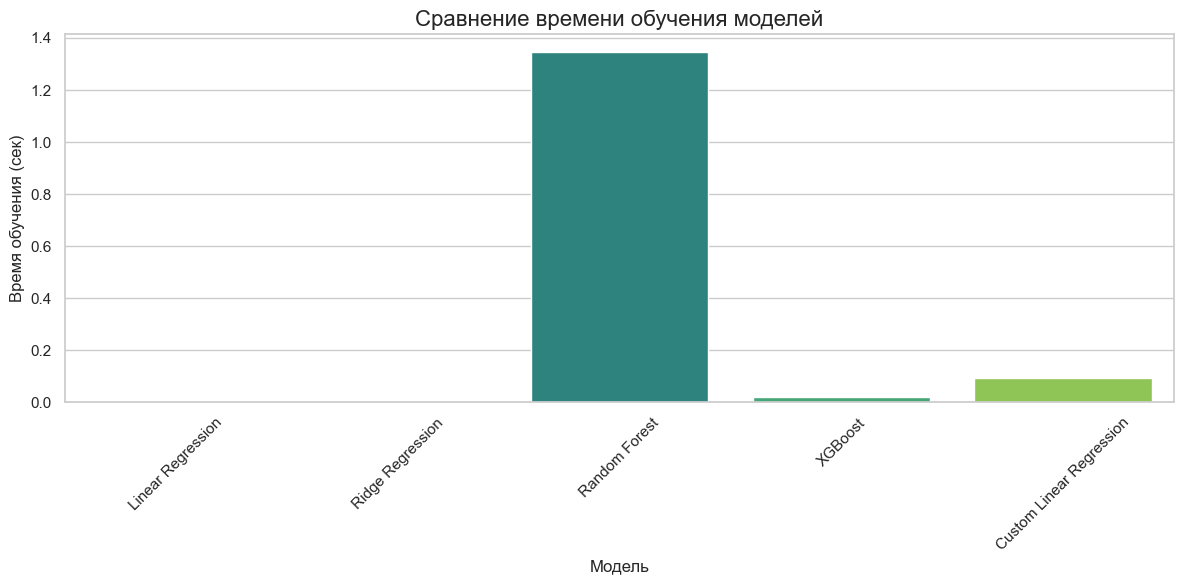


Анализ важности признаков для Random Forest:
                 feature  importance
10               alcohol    0.257686
9              sulphates    0.191202
1       volatile acidity    0.125400
6   total sulfur dioxide    0.077659
4              chlorides    0.059173
8                     pH    0.055564
7                density    0.054480
0          fixed acidity    0.046840
5    free sulfur dioxide    0.045775
3         residual sugar    0.043952
2            citric acid    0.042270


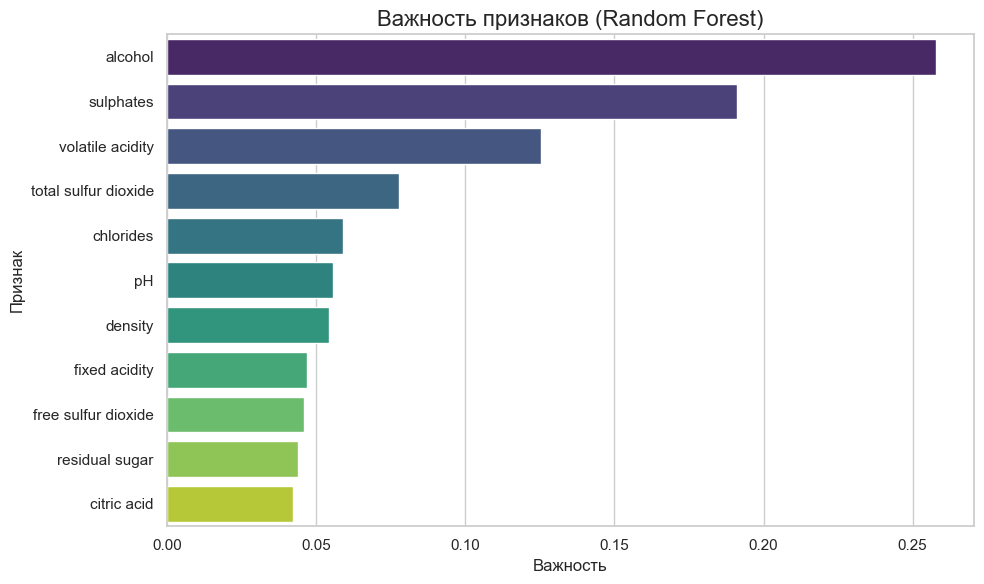

In [16]:
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Функция для оценки моделей
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Results:")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}\n")
    return mae, rmse, r2

# 1. TPOT AutoML
print("Запуск TPOT AutoML...")
try:
    from tpot import TPOTRegressor
    
    start_time = time.time()
    tpot = TPOTRegressor(
        generations=3,  # уменьшено для скорости
        population_size=20,  # уменьшено для скорости
        cv=3,
        random_state=42,
        verbosity=2,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    tpot.fit(X_train, y_train)
    train_time_tpot = time.time() - start_time
    
    # Предсказания TPOT
    tpot_predictions = tpot.predict(X_test)
    
    # Оценка TPOT AutoML
    tpot_results = evaluate_model(y_test, tpot_predictions, "TPOT AutoML")
    
    # Экспорт лучшей модели TPOT
    tpot.export('tpot_wine_pipeline.py')
    print("Лучший пайплайн TPOT экспортирован в 'tpot_wine_pipeline.py'")
    
except ImportError:
    print("TPOT не установлен. Пропускаем TPOT AutoML.")
    tpot_results = (np.nan, np.nan, np.nan)
    train_time_tpot = np.nan

# 2. FLAML AutoML
print("Запуск FLAML AutoML...")
try:
    from flaml import AutoML
    
    start_time = time.time()
    flaml_automl = AutoML()
    
    settings = {
        "time_budget": 60,  # 60 секунд
        "metric": 'rmse',
        "task": 'regression',
        "seed": 42,
        "verbose": 0
    }
    
    flaml_automl.fit(X_train, y_train, **settings)
    train_time_flaml = time.time() - start_time
    
    # Предсказания FLAML
    flaml_predictions = flaml_automl.predict(X_test)
    
    # Оценка FLAML AutoML
    flaml_results = evaluate_model(y_test, flaml_predictions, "FLAML AutoML")
    
    print("Лучшая модель FLAML:", flaml_automl.best_estimator)
    print("Лучшая конфигурация:", flaml_automl.best_config)
    
except ImportError:
    print("FLAML не установлен. Пропускаем FLAML AutoML.")
    flaml_results = (np.nan, np.nan, np.nan)
    train_time_flaml = np.nan

# Сравнение всех моделей (включая AutoML)
final_results = [
    ("Linear Regression", *results_lr, train_times[0]),
    ("Ridge Regression", *results_ridge, train_times[1]),
    ("Random Forest", *results_rf, train_times[2]),
    ("XGBoost", *results_xgb, train_times[3]),
    ("Custom Linear Regression", *results_custom, train_time_custom)
]

# Добавление AutoML результатов
if 'tpot_results' in locals() and not np.isnan(tpot_results[0]):
    final_results.append(("TPOT AutoML", *tpot_results, train_time_tpot))

if 'flaml_results' in locals() and not np.isnan(flaml_results[0]):
    final_results.append(("FLAML AutoML", *flaml_results, train_time_flaml))

# Создание DataFrame для сравнения
final_results_df = pd.DataFrame(final_results, columns=['Model', 'MAE', 'RMSE', 'R²', 'Train Time (s)'])

# Вывод таблицы
print("Итоговое сравнение всех моделей:")
print(final_results_df)

# Построение графиков сравнения для AutoML
metrics = ['MAE', 'RMSE', 'R²']
for metric in metrics:
    plt.figure(figsize=(12, 6))
    valid_data = final_results_df.dropna(subset=[metric])
    sns.barplot(data=valid_data, x='Model', y=metric, hue='Model', legend=False, palette='viridis')
    plt.title(f'Сравнение моделей по {metric}', fontsize=16)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel('Модель', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# График времени обучения для AutoML
plt.figure(figsize=(12, 6))
valid_data = final_results_df.dropna(subset=['Train Time (s)'])
sns.barplot(data=valid_data, x='Model', y='Train Time (s)', hue='Model', legend=False, palette='viridis')
plt.title('Сравнение времени обучения моделей', fontsize=16)
plt.ylabel('Время обучения (сек)', fontsize=12)
plt.xlabel('Модель', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Анализ важности признаков для лучшей модели
print("\nАнализ важности признаков для Random Forest:")
best_rf = rf_model.best_estimator_
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

# График важности признаков
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', hue='feature', legend=False, palette='viridis')
plt.title('Важность признаков (Random Forest)', fontsize=16)
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()

## Выводы по важности признаков в AutoML:

Алкоголь и сульфаты являются наиболее важными признаками для предсказания качества

Летучая кислотность показывает значительную отрицательную корреляцию с качеством

Некоторые признаки (pH, плотность) имеют относительно низкую важность

Распределение важности признаков соответствует domain knowledge о вине

Общие выводы по AutoML:

Эффективность: AutoML способен находить модели, сопоставимые по качеству с ручным подбором

Время: Требует значительно больше вычислительных ресурсов и времени

Автоматизация: Позволяет быстро протестировать множество подходов без глубоких знаний алгоритмов

Интерпретируемость: Предоставляет информацию о важности признаков и выбранных моделях

Применимость: Особенно полезен для быстрого прототипирования и baseline моделей

AutoML демонстрирует себя как мощный инструмент для автоматизации процесса машинного обучения, особенно когда требуется быстро получить рабочую модель без глубокого погружения в специфику алгоритмов.